In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/eagles.csv", separator=",").drop('').with_columns(
    proportion = pl.col("y")/pl.col("n"),
    pirate_large=(pl.col("P") == "L").cast(pl.Int8),
    pirate_adult=(pl.col("A") == "A").cast(pl.Int8),
    victim_large=(pl.col("V") == "L").cast(pl.Int8),
).drop("P", "A", "V")

In [3]:
with pm.Model() as binom_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1.5)
    beta_p = pm.Normal("beta_pirate_large", mu=0, sigma=0.5)
    beta_v = pm.Normal("beta_victim_large", mu=0, sigma=0.5)
    beta_a = pm.Normal("beta_pirate_adult", mu=0, sigma=0.5)

    probs = pm.Deterministic(
        "probs",
        pm.invlogit(alpha +
                    beta_p*df["pirate_large"].to_numpy() +
                    beta_v*df["victim_large"].to_numpy() +
                    beta_a*df["pirate_adult"].to_numpy())
    )

    successes = pm.Binomial("y", n=df["n"].to_numpy(), p=probs, observed=df["y"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["y", "probs"])

    # sample å
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior, var_names=["y", "probs"])
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta_pirate_adult, beta_pirate_large, beta_victim_large, y]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_pirate_large, beta_victim_large, beta_pirate_adult]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [y]


Output()

Output()

In [ ]:
with pm.Model() as binom_interaction_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1.5)
    beta_v = pm.Normal("beta_victim_large", mu=0, sigma=0.5)
    beta_p = pm.Normal("beta_pirate_large", mu=0, sigma=0.5, shape=2)

    probs = pm.Deterministic(
        "probs",
        pm.invlogit(alpha
                    + beta_p[df["pirate_adult"].to_numpy()]*df["pirate_large"].to_numpy()
                    + beta_v*df["victim_large"].to_numpy()
    )
    )

    successes = pm.Binomial("y", n=df["n"].to_numpy(), p=probs, observed=df["y"].to_numpy())

    # sample priors
    prior_predictive_interaction = pm.sample_prior_predictive(var_names=["y", "probs"])

    # sample å
    posterior_interaction = pm.sample(chains=4)
    posterior_predictive_interaction = pm.sample_posterior_predictive(posterior_interaction, var_names=["y", "probs"])
    pm.compute_log_likelihood(posterior_interaction)

Sampling: [alpha, beta_pirate_large, beta_victim_large, y]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_victim_large, beta_pirate_large]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [y]


Output()

Output()

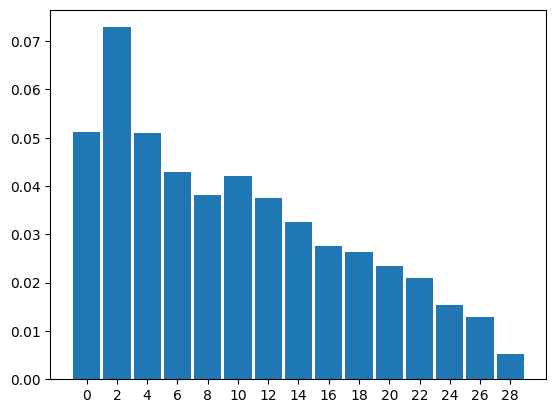

In [5]:
ax = az.plot_dist(
    prior_predictive_interaction.prior_predictive["y"],
    kind="hist",
)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_victim_large'}>,
        <Axes: title={'center': 'beta_victim_large'}>],
       [<Axes: title={'center': 'beta_pirate_large'}>,
        <Axes: title={'center': 'beta_pirate_large'}>],
       [<Axes: title={'center': 'probs'}>,
        <Axes: title={'center': 'probs'}>]], dtype=object)

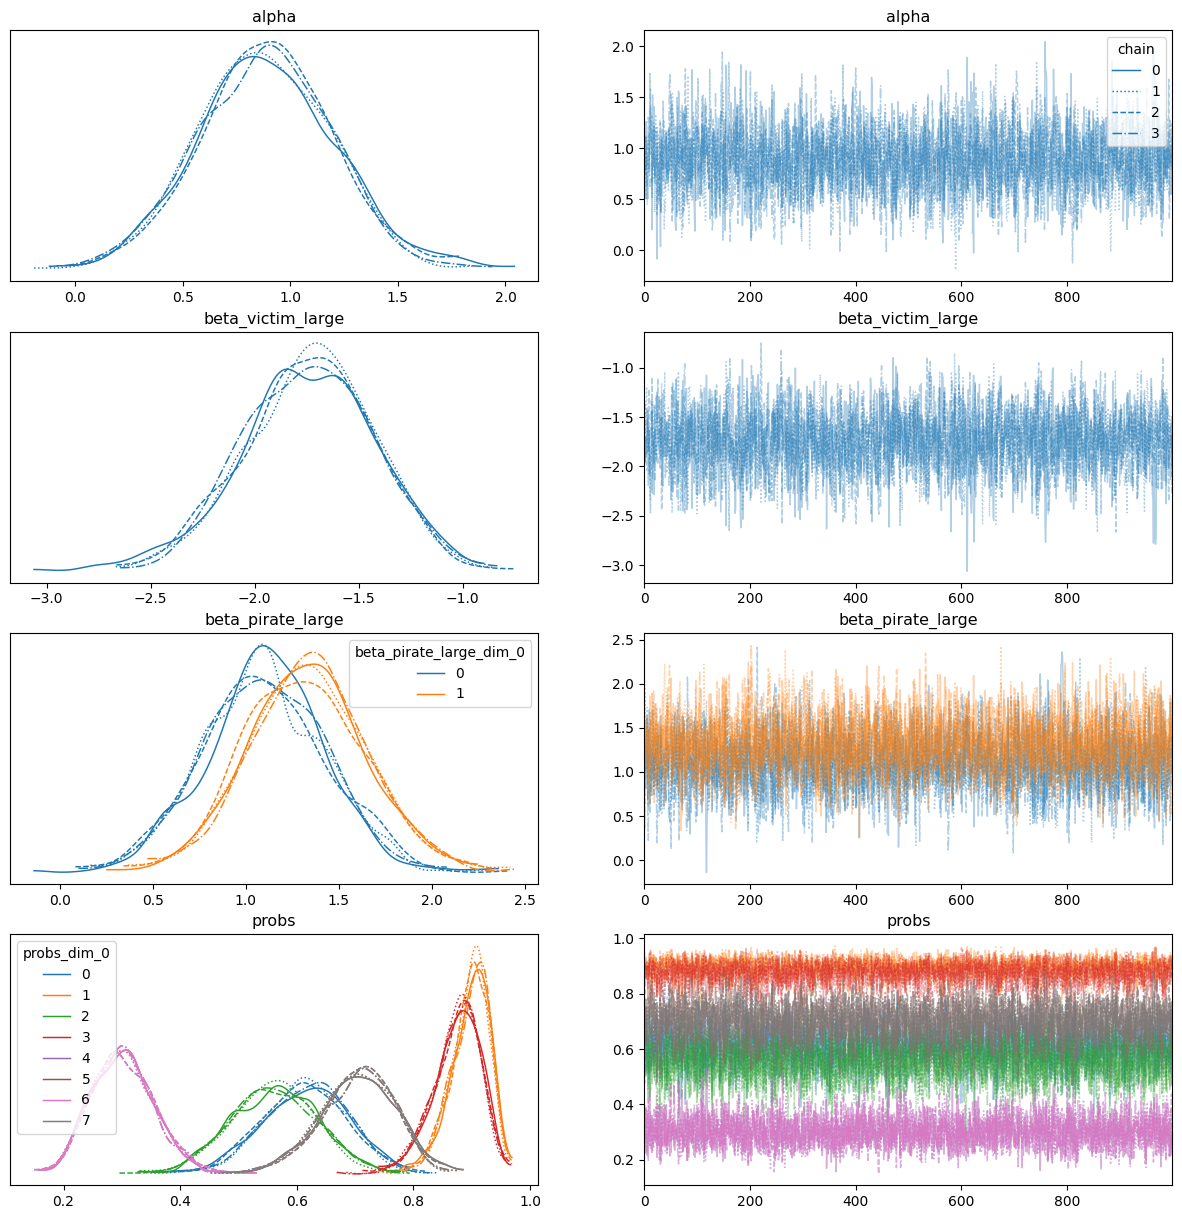

In [12]:
az.plot_trace(posterior_interaction,figsize=(15,15), legend=True)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_pirate_large'}>,
        <Axes: title={'center': 'beta_pirate_large'}>],
       [<Axes: title={'center': 'beta_victim_large'}>,
        <Axes: title={'center': 'beta_victim_large'}>],
       [<Axes: title={'center': 'beta_pirate_adult'}>,
        <Axes: title={'center': 'beta_pirate_adult'}>],
       [<Axes: title={'center': 'probs'}>,
        <Axes: title={'center': 'probs'}>]], dtype=object)

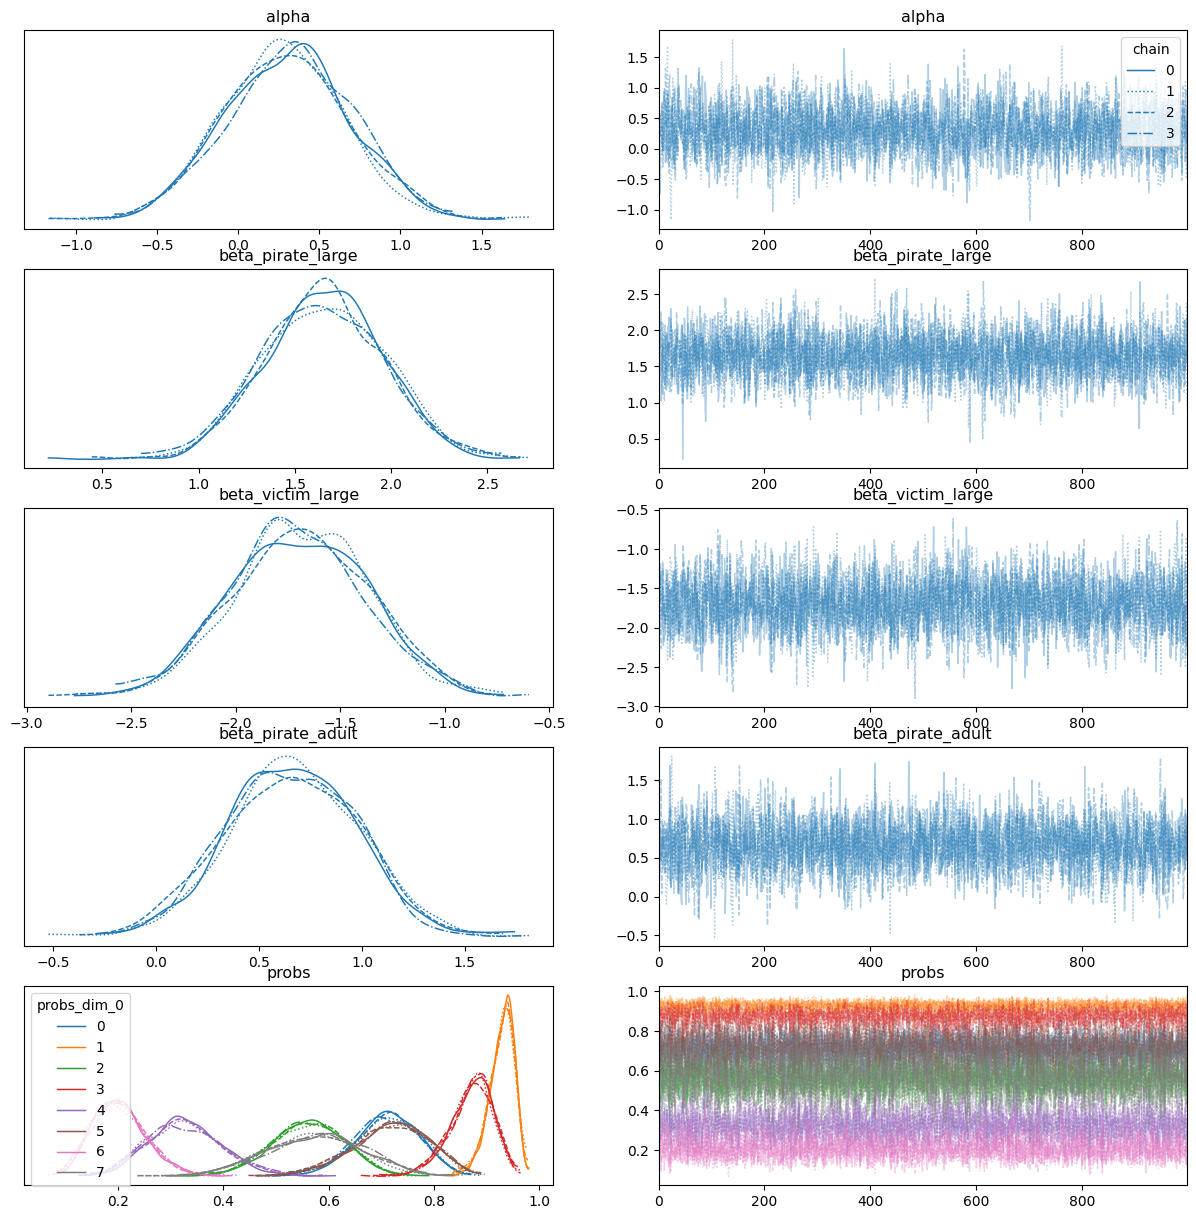

In [13]:
az.plot_trace(posterior,figsize=(15,15), legend=True)

In [14]:
df = extract_quantile_columns(
    df=df,
    posterior_predictive=posterior_predictive.posterior_predictive,
    outcome_name="probs",
    prefix="basic"
)

df = extract_quantile_columns(
    df=df,
    posterior_predictive=posterior_predictive_interaction.posterior_predictive,
    outcome_name="probs",
    prefix="interaction"
)


In [15]:
comparison = az.compare({
    "binom_basic_model": posterior,
    "binom_interaction_model": posterior_interaction,
}, scale="deviance")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
binom_basic_model,0,60.758547,9.284600,0.000000,1.000000e+00,12.362614,0.000000,True,deviance
binom_interaction_model,1,75.226143,11.315952,14.467597,3.996803e-15,19.509960,8.773216,True,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

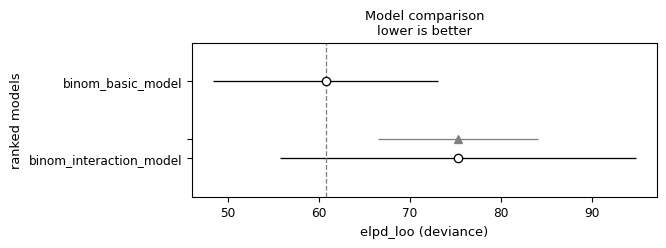

In [16]:
az.plot_compare(comparison, plot_ic_diff=True)

In [17]:
df

y,n,proportion,pirate_large,pirate_adult,victim_large,basic_probs_11.0,basic_probs_89.0,interaction_probs_11.0,interaction_probs_89.0
i64,i64,f64,i8,i8,i8,f64,f64,f64,f64
17,24,0.708333,1,1,1,0.631405,0.784522,0.524526,0.701459
29,29,1.0,1,1,0,0.8972,0.954853,0.853682,0.934582
17,27,0.62963,1,0,1,0.47611,0.645716,0.469576,0.651191
20,20,1.0,1,0,0,0.816255,0.917386,0.822271,0.920165
1,12,0.083333,0,1,1,0.241454,0.417282,0.23767,0.367469
15,16,0.9375,0,1,0,0.624215,0.804426,0.623964,0.780631
0,28,0.0,0,0,1,0.142228,0.267445,0.23767,0.367469
1,4,0.25,0,0,0,0.45667,0.683387,0.623964,0.780631
